'''  
- 합성곱 신경망 CNN
  - CNN 전체 구조
  - CNN 모델
- 이미지 딥러닝 응용
- RNN
  - RNN 구조와 원리
  - RNN 한계
- LSTM과 GRU
- Seq2Seq
  - Seq2Seq 개념
  -Encoder-Decoder 구조  
  
'''

# 합성곱 신경망
## 픽셀과 채널
- 픽셀: 입력 이미지의 가장 기본적인 데이터 단위 -> 이미지의 각 점의 정보 저장
- 채널: 픽셀의 색을 숫자로 표현하는 방식(색공간)
  - 그레이 스케일: 흑백이미지의 명도를 숙자로 표현. 채널값 = 1. 0~2의 unsigned int로 표현
  - RGB: 빨강, 초록, 파랑 3가지 색의 명도를 합쳐서 하나의 색을 형성. 채널값 = 3
  - RGBA: A = alpha. 4차원 배열로 저장

## CNN
- if) 픽셀 정보만 학습  
  -> 픽셀 각각의 정보를 학습하즌 것이기 때문에 하나로 합쳐서 생각 x -> 이미지의 특징 파악 불가
- CNN은 이미지 공간 정보(각 영역의 특징)를 유지하면서 학습
  - MLP의 FC Layer 앞에 **(Conv+Pool)** 단게를 추가한 것
- 이미지 처리에서 MLP vs CNN  

| 비교 항목 | MLP (Multi-Layer Perceptron) | CNN (Convolutional Neural Network) |
|---|---|---|
| Translation Variant (위치 변화 대응) | 이미지의 위치, 크기, 회전 변화에 취약함 → 입력값 변화가 커져 학습한 가중치가 잘 동작하지 않음 → 성능 저하 | Convolution으로 특징(feature)을 추출하고 Pooling으로 차원을 축소 → 위치 변화와 무관하게 특징 학습 가능 |
| Parameter Explosion (파라미터 폭증) | 완전 연결(Fully Connected) 구조 → 파라미터 수 급증 → 과적합 위험 증가 및 학습 속도 저하 | 부분 연결(Local Connection) + Convolution 연산 사용 → 필요한 특징에만 집중하여 파라미터를 효율적으로 사용 |
| 공간 정보 처리 | 픽셀을 1차원으로 펼쳐(flatten) 처리 → 이미지의 공간 정보 손실 발생 | Convolution 과정에서 공간 정보를 유지하며 학습 → 특징 추출 후 flatten 하므로 손실이 상대적으로 적음 |

### CNN 모델의 구조
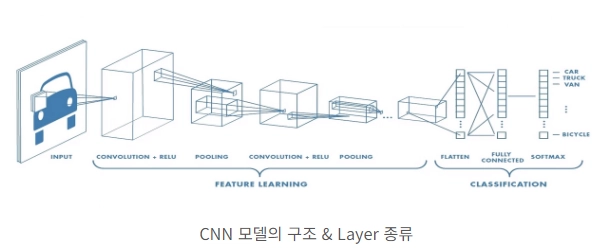  
- 특징 추출 영역: **Convolution Layer**와 **Pooling Layer**를 여러 겹 쌓는 형태로 구성
  -Convolution layer: 입력 데이터 -> 필터 -> 활성화 함수
  - Pooling layer: 이미지 축소 -> 중요한 특징 강조 -> 과적합 방지
- 이미지 분류 영역: CNN 모델의 마지막에 위치. Fully Connected Layer로 구성

### 합성곱과 풀링
- Convolution Layer: 전체 이미지를 **일정 크기의 필터**로 훑으면서 이미지의 특징 학습
  1. 필터(또는 커널)이 이미지 슬라이딩: 필터값 = 가중치 역할
  2. 각 위치에서 요소별 곱셈 후 합계 계산
  3. 결과를 피쳐맵에 저장: 피쳐맵 = 입력 데이터에 필터를 적용해 얻은 결과물
- Padding: 필터를 거치며 발생하는 정보 손실을 막기 위해 **이미지 바깥을 0으로 둘러싸는 기법** -> 가장자리 특징까지 반영 가능
- Stride: 이미지를 **몇 칸씩 점프**하면서 훑을 것인지 결정하는 값  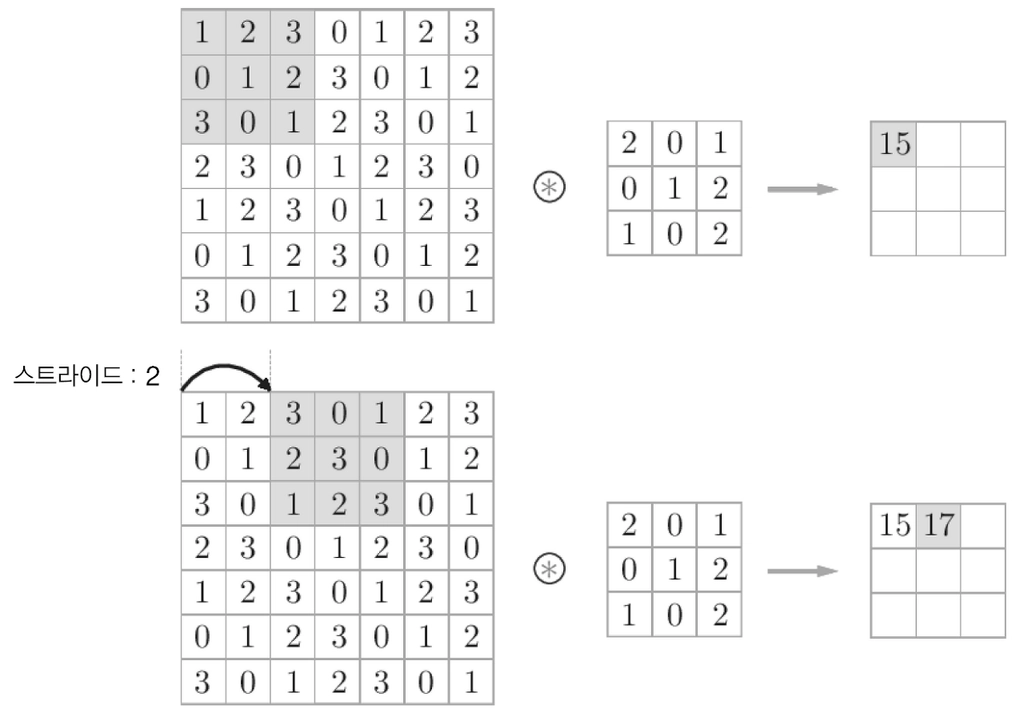  
  -> Stride가 클수록 피쳐맵 크기 작아짐
- Pooling: 피처맵에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역 안에서 가장 큰 값 또는 평균값을 취하는 것  
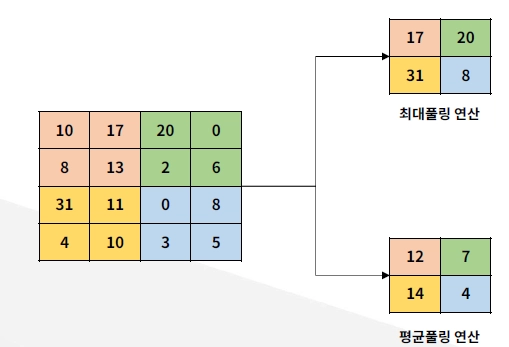  
  - 종류
    - max pooling: 최댓값 선택
    - average pooling: 평균값 선택
  - 장점
    - **모델 용량 및 계산량 감소**
    - 노이즈 제거 -> 중요한 피쳐만 유지 -> **과적합 방지**
  - 단점
    - 정보 소실 위험

### 대표적인 CNN 아키텍쳐
- AlexNet: 머신러닝에서 벗어나 최초로 GPU를 이용해 학습한 대규모 CNN 모델
  - 5개의 Convolutional Layer + 3개의 Fully Connected Layers 
  - ReLU 함수 이용 -> 기울기 소실 문제 해소
  - Dropout -> 과적합 방지
- VGGNet: 이미지 인식에 강한 깊은 층의 CNN 모델
  - Conv + Pool(max) 여러번 반복
  - 이미 만들고 학습시킨 VGGNet 모델을 가져와 사용하는 전이 학습에 많이 사용
  - 초반 연산량 많지만 정확도 높음
- ResNet: 잔차 연결 개념을 도입해 깊은 신경망의 소실 문제를 해결한 모델
  - 잔차 연결이란? 이전 레이어의 출력을 몇 레이어를 건너뛰고 다음 레이어의 입력으로 직접 추가하는 방식





# 이미지 딥러닝 응용
## 이미지 분류
- 개념: 이미지를 수치 데이터(픽셀 값)로 인식 → 사전 정의된 클래스 중 하나로 분류
- 
    | 모델명 | 특징 요약 | 주의사항 |
    | --- | --- | --- |
    | **AlexNet** | 비교적 단순한 구조, 초기 CNN 모델들 | 작은 데이터셋이나 학습 개념 설명용으로 적절 |
    | **VGG** | 더 깊은 구조, 복잡한 블록 구조 적용 | 계산량 증대, 메모리 요구 높음 |
    | **ResNet** | Residual 연결 (skip connections) → 매우 깊은 네트워크 가능 | 과적합 주의, batch size / regularization 조절 필요 |
    | **Vision Transformer (ViT)** | Transformer 구조 응용 → 패치 기반 입력 처리 | 이미지와 순차 처리 모델의 결합, 대규모 데이터 필요 |

## 객체 탐지
- 개념: 객체 검출(object detection)은 한 이미지에서 객체와 이 객체를 둘러싸는 가장 작은 직사각형으로 정의되는 bounding box를 찾는 작업
- CNN을 통해 Feature Map을 얻고, 그 위에 두 가지 head를 올리는 방식
    - Classification Head: 객체의 클래스 예측
    - Regression Head: 객체의 위치 좌표 예측

## 이미지 캡셔닝
- 개념: 이미지 내에 있는 객체에 대한 판단뿐만 아니라 객체들 간의 관계를 파악하고 자연어의 형태로 알맞게 표현
- 단계
    1. CNN을 이용한 특징 추출: 인풋 데이터를 ResNet-101을 이용해 특징 추출
    2. Attention Network를 이용해 단어 생성: 중요한 부분에 가중치를 두고 가중치가 높은 부분을 통해 사진을 한 문장으로 설명할 수 있게 함
    3. RNN을 이용해 문장 완성: 가중치를 바탕으로 추출한 이미지의 주요 단어들을 RNN으로 조합

# RNN
## 순차 데이터란?
- 정의: 순서에 의미가 있으며, 순서가 달라질 경우 의미가 손상되는 데이터
- 예시: 음성 및 오디오 데이터, 자연어, 생물학적 서열 데이터, 비디오 데이터
- 기존 정형데이터 vs 순차 데이터

    | 구분        | 일반적인 정형 데이터              | 순차 데이터                                           |
    | --------- | ------------------------ | ------------------------------------------------ |
    | 데이터 구조    | 행(Row)과 열(Column) 기반의 구조 | 시간 또는 순서 기반의 연속된 데이터 구조                          |
    | 요소 간 관계   | 각 샘플(행)이 서로 독립적          | 이전 데이터와 이후 데이터가 서로 연결됨                           |
    | 순서의 중요성   | 행 순서가 바뀌어도 의미 변화 없음      | 요소의 순서 자체가 핵심 정보                                 |
    | 특성(열) 순서  | 열 순서가 바뀌어도 정보 자체는 동일     | 순서가 바뀌면 데이터 의미가 달라질 수 있음                         |
    | 주요 특징     | 독립성(Independence)        | 순서 의존성(Order Dependency), 자기상관성(Autocorrelation) |
    | 데이터 영향 관계 | 특정 행이 다른 행에 영향을 주지 않음    | 이전 시점 데이터가 다음 시점 데이터에 영향을 미침                     |
    | 예시        | 고객 정보 테이블, 학생 성적표        | 주가 데이터, 음성 데이터, 문장, 센서 로그                        |

## RNN의 구조와 원리
- RNN: **순환하는 구조**를 가진, 순차 데이터 처리에 특화된 인공 신경망
- 원리
    1. 시퀀스 데이터를 입력받아 **순서 정보를 유지**하며 처리
    2. 순환하는 은닉층이 매 시점의 은닉 상태 업데이트
    3. **이전 시점의 값을 현재 시점으로 전달**
    -> 핵심: 동일한 가중치를 시퀀스의 다양한 시점에서 반복적으로 적용 **(가중치 공유)**
    -> **학습 파라미터의 수 감소, 일반화 능력 향상**
- 구조: 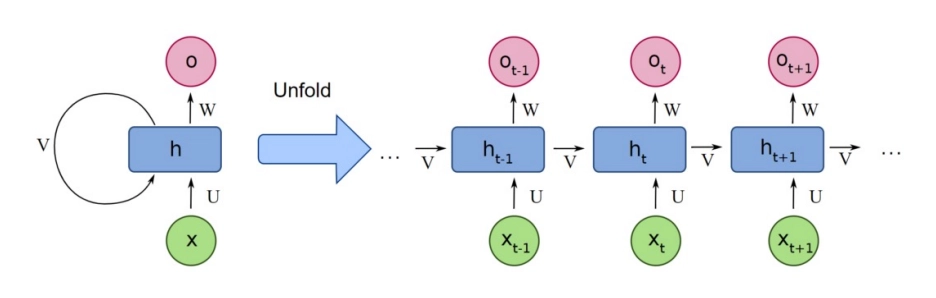  
    - 초록색 = 입력층, 파란색 = 은닉층, 분홍색 = 출력층
    - U = 입력 가중치. 현재 시점 t의 입력이 은닉상태에 영향을 주는 가중치
    - V = 순환 가중치. 이전 시점 t-1의 은닉 상태가 현재 은닉 상태에 영향을 주는 가중치
    - W = 출력 가중치. 현재 시점 t의 은닉 상태가 최종 출력에 영향을 미치는 가중치
- 정보의 흐름
    - t-1 시점: 입력 $x_{t-1}$이 들어가면, 이를 이용해 은닉 상태 $$h_{t-1}$ 을 업데이트하고 출력 $o_{t-1}$ 을 생성한다.
    - t 시점: 이전 시점에서 계산된 은닉 상태 $h_{t-1}$ 이 다음 시점으로 전달된다.
    - 현재 시점의 계산: 새로운 입력 $x_t$ 와 전달받은 과거 정보 $h_{t-1}$을 함께 사용하여 현재 은닉 상태 $h_t$를 업데이트한다.
    - 출력 생성: 업데이트된 은닉 상태 $h_t$를 기반으로 출력 $o_t$를 계산한다.
    -> **은닉 상태의 순환을 통해 과거의 정보를 다음 시점으로 계속해서 전달**

## RNN의 한계 및 장기 의존성 문제
- RNN은 전체 시퀀스를 모두 읽은 후 역전파가 이루어지므로 역전파를 구하는 과정에서 연쇄법칙에 의해 다음 미분값이 반복적으로 곱해진다. 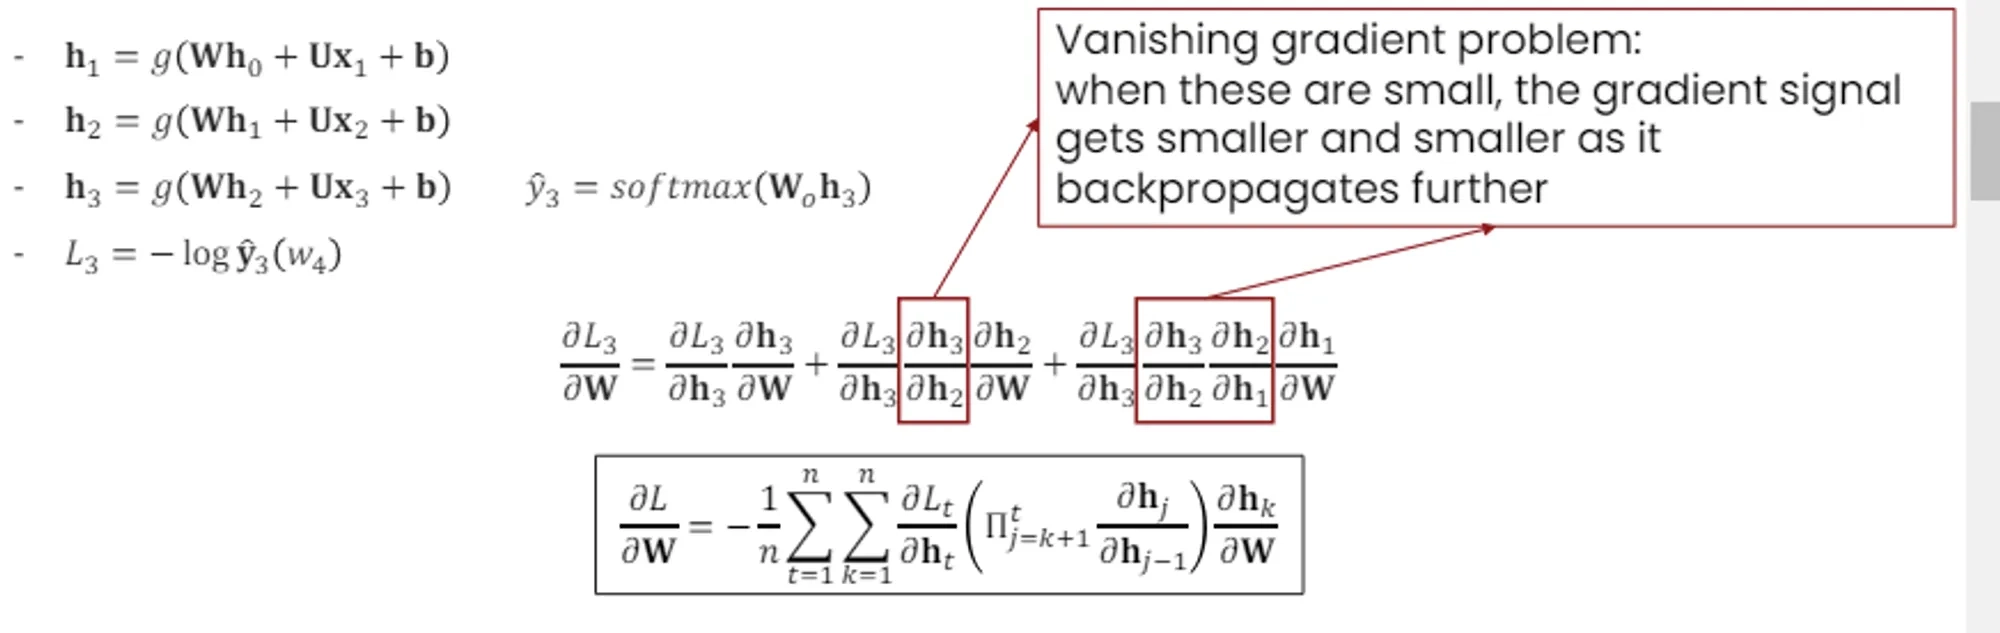
- 한계
    - **기울기 소실**: 역전파 과정에서 반복적으로 곱해지는 기울기(미분값)의 크기가 1보다 작을 때 기울기가 0으로 수렴 -> 먼 과거의 정보를 학습하지 X
    - **기울기 폭주**: 역전파 과정에서 반복적으로 곱해지는 기울기(미분값)의 크기가 1보다 클 때 기울기가 무한대로 발산 -> 시퀀스 뒤쪽의 오차가 비정상적으로 커짐
    - **느린 훈련 시간**: 앞 시점의 은닉상태가 먼저 계산되어야 현재 시점 계산이 가능하므로 한 번에 병렬 처리 불가능
- **장기 의존성 문제**: 시퀀스 앞 부분의 중요한 정보를 잊어버려 맥락 파악 능력이 급격히 저하되는 현상 -> RNN의 기억력 한계를 극복하는 새로운 모델의 필요성 대두 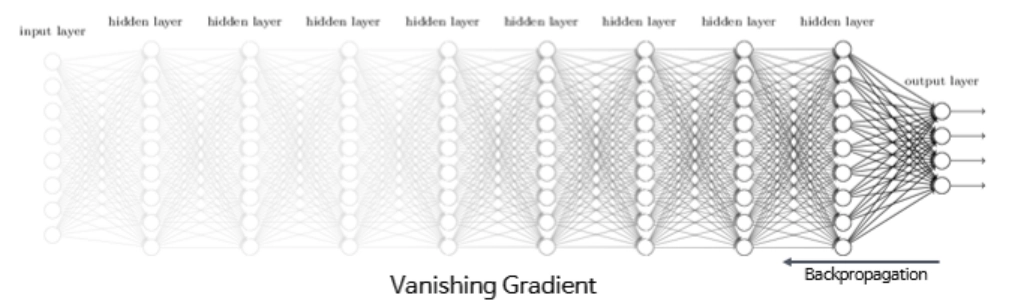



# LSTM과 GRU
- 셀 상태($C_T$): 장기 기억 -> 절대 변하지 않는 핵심 기억
- 엘리트: 셀 상태에서 현재 필요한 기억만 꺼낸 것 -> 현시점에서의 판단 또는 출력으로 사용
- LSTM: 잊을 건 잊고, 기억할 건 기억해서 핵심 기억을 바탕으로 행동(출력 결과) 결정 -> 장기기억과 단기기억 및 출력을 따로 분리해서 관리, but 복잡하다
- GRU: 모든 기억과 행동이 하나의 상태($h_t$)로 통합 -> 단순하고 즉각적. LSTM보다 정교함 낮음
    - Update gate: 현재 상태를 만들 때 과거 기억(0.3)과 새 정보(0.7)의 비율 조정
    - Reset gate: 현재 입력이 중요하면 과거 기억 잠시 무시

## LSTM
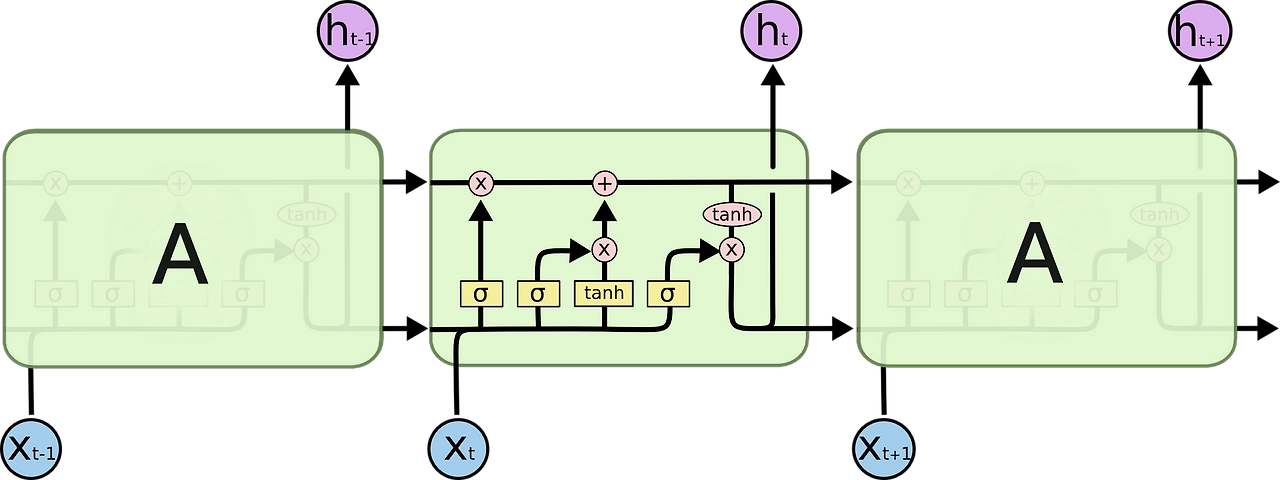  
- 노란색 = Neural Network Layer, 분홍색 = Pointwise Operation(각 원소마다 독립적으로 수행하는 연산)
- 개념: Long Short Term Memory. 앞의 정보가 뒤로 충분히 전달되지 못하는 RNN의 기울기 소실 문제 해결
    - HOW? **기억할 내용과 잊어버릴 내용을 선택해서, 중요한 정보들을 오래 가져감** -> Gate를 통해 곱셈을 덧셈으로 바꾼다
- RNN과 달리 $c_t$(장기기억)와 $h_t$(단기기억)의 **2개의 순환되는 층** 사용 (RNN은 $h_t$ 하나)
- 구성
    - Forget gate: 정보를 얼마나 **잊어버릴지** 결정
    - Input gate: **현재 정보를 얼마나 사용할지** 결정
    - Output gate: 다음 층으로 **어떤 정보를 전달할지** 결정
    - Final memory cell: 입력과 forget gate를 결합해 현재 정보를 얼마나 **기억할지** 계산
- 장점: 기울기 소실 문제 완화: 이전의 정보가 완전히 보존되는 상태로 은닉층 갱신 가능
- 단점: RNN보다 학습 파라미터 많아짐 -> 많이 복잡함
- 적합한 경우
    - 긴 시퀀스에서 문맥 이해가 중요한 작업
    - 데이터 양이 충분하고 복잡한 패턴을 학습해야 하는 경우
    - 모델 성능이 계산 효율보다 더 중요한 경우
    - 기계 번역, 언어 모델링, 장기 시계열 예측
## GRU
- LSTM에서 별도의 메모리 셀 없이 게이트 수를 줄여 구조를 간소화한 것
    - forget gate와 input gate를 update gate 하나로 합침
    - reset gate 사용
    -> gate가 2개기 때문에 학습 시간이 줄어든다
- 장점: 성능과 효율성 사이의 균형이 좋다
- 단점: 긴 시퀀스 처리에서의 한계 존재
- 적합한 경우
    - 자원이 제한적이거나 학습 속도가 중요한 경우
    - 데이터 양이 적고 과적합 위험이 있는 경우
    - 실시간 예측이 필요한 응용
    - 사용 예시: 음성 인식, 스트리밍 데이터, 실시간 비디오 분석, 짧은 시퀀스 기반의 텍스트 분류

# Seq2Seq
- 개념: 한 시퀀스를 다른 시퀀스로 변환하는 작업을 수행하는 딥러닝 모델로, 대표적으로 기계번역에서 사용 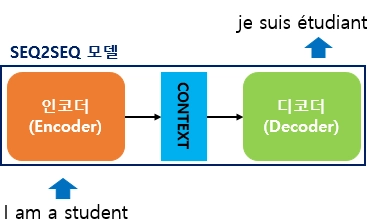  
- 인코더: 입력된 시퀀스를 읽고 의미를 정리하는 역할. 여러 개의 정보를 하나의 **컨텍스트 벡터**로 압축
    - 입력: t 시점의 임베딩된 단어의 입력과 t-1 시점의 은닉 상태
    - 출력: t 시점의 은닉 상태
- 디코더: 컨텍스트 벡터를 받아서 결과를 만드는 역할. 새로운 결과인 Sequence 출력
    - t시점에 나온 출력값 = 그 다음 시점의 입력값
- 특징
    - 입력과 출력의 길이가 달라도 가능
    - 인코더와 디코더 분리: 의미 이해 과정과 결과 생성 과정이 명확히 분리 -> 인코더-디코더 모델
    - 문맥 벡터 존재: float형의 백터로, 인코더 중 마지막 시점의 은닉 상태
- 한계: 병목현상 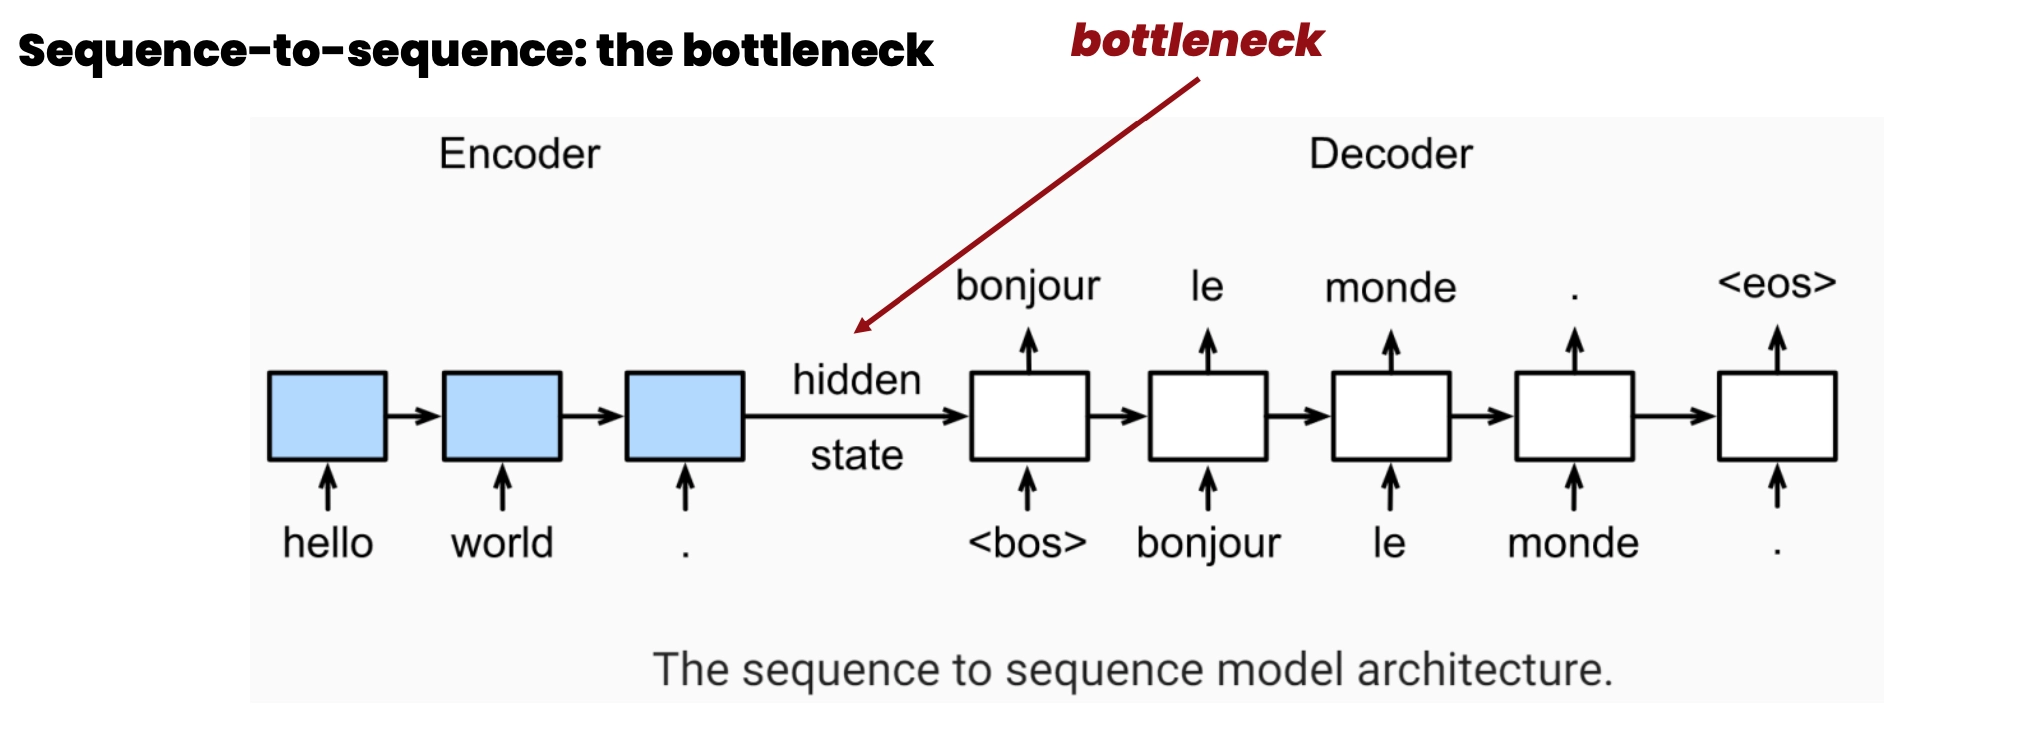
    - 문맥 벡터의 길이가 고정된 경우, 소스 문장의 정보를 압축하는 과정에서 정보 손실 발생 -> 모델 성능 하락